# Hailsonde + balloon buoyancy (`w_buoy_balloon`) and updraft-drag of balloon uncertainty (`eps_balloon_upd-drag`)

ICECHIP hailsonde campaign — 20 g balloon, 0.60 m launch diameter,
in **two payload versions** (v1 = 25 g, v2 = 20 g) identified by sonde ID.

Follows the framework of **Marinescu et al. (2020)**, *Mon. Wea. Rev.* **148**, 4435–4452
(§2a and Appendix B), but re-derives every number for this flight train rather than
adopting theirs. Their values (`w_buoy` = 4.8 ± 1.1 m/s, `eps_upd-drag` = ±1.6 m/s) are for
a 200 g balloon on a 30 m dereeler and do not transfer.

**What this notebook computes**

1. `w_buoy_balloon` — the still-air ascent rate of each version, from two independent
   routes: the *observed* clear-air ascent rate, and the *theoretical* terminal velocity
   from the balloon specification (Eq. B1).
2. `eps_upd-drag` — the uncertainty in `w_air` arising from the drag coefficient inside an
   updraft differing from clear air, again by two routes.
3. A diagnostic comparing the two, which decides how much of the observed ascent rate is
   buoyancy and how much is real air motion. **This turns out to be the main result.**

**Input:** `v2026/<yyyymmdd>/<category>/<stem>.alt.csv` (the new Sparv retrieval).
Read directly so this notebook stands alone; it does not depend on `compare_alt_rise.py`.

**Output:** `wbuoy_drag_per_launch.csv`, `wbuoy_drag_profile.csv`,
`wbuoy_drag_summary.csv`, and three figures.

In [7]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================== PARAMETERS ==================================
# Flight train ---------------------------------------------------------------
M_BALLOON = 0.020      # kg   balloon mass                              [given]
D_LAUNCH  = 0.55       # m    balloon diameter at launch                [given]

# Two hailsonde versions, identified by the sonde ID in the filename stem
# (<date>_<time>_<id>[_merged]).  Payload = sonde + line + any dereeler.
PAYLOAD    = {"v1": 0.025, "v2": 0.020}    # kg                         [given]
V2_ID_MIN  = 15312     # ids at or above this, and <= V2_ID_MAX, are v2
V2_ID_MAX  = 15399

# Drag coefficient range for a sphere in the relevant Reynolds regime.
# Marinescu et al. take 0.2-0.5 from Achenbach (1972), Son et al. (2010) and
# Gallice et al. (2011).  Inherited, NOT derived here - see the caveats at the end.
CD_MIN, CD_MAX = 0.20, 0.50   # dimensionless
CD_ANCHOR      = 0.35  # central value used for the recommended w_buoy

# Clear-air ascent segment: above the launch transient, below cloud base.
AGL_LO, AGL_HI = 100.0, 500.0   # m AGL

DATA = Path("/home/meso/data/icechip-hailsonde-data/v2026")   # root of the Sparv .alt.csv tree
OUT  = Path.cwd()                                              # where figures are written
# ============================================================================

# physical constants
G       = 9.80665              # m/s2, standard gravity
R_DRY   = 287.05               # J/kg/K, gas constant for dry air
M_RATIO = 4.0026 / 28.9647     # helium / dry air molar mass -> density ratio
C_TO_K  = 273.15               # K, offset from degrees Celsius to kelvin

# balloon geometry at launch, treated as a sphere of diameter D_LAUNCH
V_LAUNCH = (4.0 / 3.0) * np.pi * (D_LAUNCH / 2.0) ** 3   # m3
A_LAUNCH = np.pi * (D_LAUNCH / 2.0) ** 2                 # m2

# echo the flight-train setup
print(f"launch volume {V_LAUNCH:.4f} m3   cross-section {A_LAUNCH:.4f} m2")
for v, m in PAYLOAD.items():
    print(f"  {v}: payload {m*1e3:.0f} g")

launch volume 0.0871 m3   cross-section 0.2376 m2
  v1: payload 25 g
  v2: payload 20 g


## 1. Load

One row per transmitted sample. `Rise speed` is Sparv's barometric retrieval; `GPS rise
speed` is the receiver's own velocity solution and is carried alongside as an independent
check — it is not affected by the non-hydrostatic pressure perturbations that contaminate a
barometric rise speed inside an updraft.

The sonde ID is the third underscore-separated field of the stem, and sets the payload
version.

In [8]:
def _num(s):
    """Blank-padded fields ('  ') -> NaN."""
    return pd.to_numeric(s.astype(str).str.strip().replace("", np.nan), errors="coerce")


def sonde_id(stem):
    """
    Sonde ID from a sounding's filename stem.

    Parameters
    ----------
    stem : str
        Filename stem, <date>_<time>_<id>[_merged].

    Returns
    -------
    sonde_id : int
        The third underscore-separated field.
    """
    return int(stem.split("_")[2])


def sonde_version(stem):
    """
    Hailsonde payload version from the sonde ID.

    IDs below V2_ID_MIN are v1; IDs from V2_ID_MIN to V2_ID_MAX are v2.

    Parameters
    ----------
    stem : str
        Filename stem, <date>_<time>_<id>[_merged].

    Returns
    -------
    version : str or None
        "v1" or "v2", or None (with a warning) for an ID outside both ranges.
    """
    sid = sonde_id(stem)
    if sid < V2_ID_MIN:
        return "v1"
    if sid <= V2_ID_MAX:
        return "v2"

    # unknown flight train: excluded downstream (NaN payload), so say so here
    warnings.warn(
        f"sonde id {sid} in {stem} is outside the known ranges "
        f"(v1 < {V2_ID_MIN}, v2 {V2_ID_MIN}-{V2_ID_MAX}); sounding excluded"
    )
    return None


def load(root=DATA):
    """
    Read every Sparv altitude retrieval under `root` into one long table.

    Parameters
    ----------
    root : Path
        Directory searched recursively for <stem>.alt.csv files.

    Returns
    -------
    d : DataFrame
        One row per transmitted sample, all soundings concatenated. Columns:
        case, sonde_id, version, category, t (s from launch), alt (m MSL),
        agl (m AGL), rise and rise_gps (m/s), temp (C), p (Pa).
    """
    # list (dim: sounding) of DataFrame (dim: sample)
    frames = []
    for f in sorted(root.rglob("*.alt.csv")):
        # read one file; the first two lines are '#' comments
        stem = f.name[: -len(".alt.csv")]
        df = pd.read_csv(f, skiprows=2, skipinitialspace=True)
        df.columns = [c.strip() for c in df.columns]

        # keep the fields used below, under short names
        g = pd.DataFrame({
            "case":     stem,
            "sonde_id": sonde_id(stem),
            "version":  sonde_version(stem),
            "category": f.parent.name,                          # updraft / proximity
            "t":        _num(df["Time from launch (sec)"]),     # s
            "alt":      _num(df["Altitude (m MSL)"]),           # m MSL
            "agl":      _num(df["Height (m AGL)"]),             # m AGL
            "rise":     _num(df["Rise speed (m/s)"]),           # m/s, barometric
            "rise_gps": _num(df["GPS rise speed (m/s)"]),       # m/s, GPS velocity
            "temp":     _num(df["Temperature (C)"]),            # C
            "p":        _num(df["Pressure (Pa)"]),              # Pa
        })

        # drop rows with no time or altitude, remove repeated timestamps, order by time
        g = g.dropna(subset=["t", "alt"])
        g = g.drop_duplicates("t")
        g = g.sort_values("t")
        frames.append(g)
    return pd.concat(frames, ignore_index=True)


d = load()

# derived per-sample fields
d["rho_f"] = d["p"] / (R_DRY * (d["temp"] + C_TO_K))   # kg/m3, dry-air density (T, not T_v)
d["m_pay"] = d["version"].map(PAYLOAD)                 # kg, payload mass for this version

print(f"{d.case.nunique()} soundings, {len(d):,} samples")
print()

# soundings per version, with the id range each covers
ver = d.groupby("case").version.first()    # Series (dim: case), payload version
sid = d.groupby("case").sonde_id.first()   # Series (dim: case), sonde id
for v in ("v1", "v2"):
    s = sid[ver == v]
    print(f"  {v} ({PAYLOAD[v]*1e3:.0f} g payload): {len(s):2d} soundings, "
          f"ids {s.min()}-{s.max()}")
print()

# soundings per category and version
category = d.groupby("case").category.first()   # Series (dim: case), updraft / proximity
print(pd.crosstab(category, ver).to_string())

61 soundings, 87,608 samples

  v1 (25 g payload): 25 soundings, ids 9501-15303
  v2 (20 g payload): 36 soundings, ids 15312-15395

version    v1  v2
category         
proximity   9  15
updraft    16  21


## 2. Skip unusable files

A handful of files carry no usable sub-cloud segment — telemetry that never spans
`AGL_LO`–`AGL_HI`, an altitude discontinuity, or a descent-only record. They are listed
explicitly below rather than detected, so the exclusion is auditable and stable.

Also excluded are launches whose median rise through the band falls outside 1–8 m/s.
The low end catches records that drift rather than ascend; the high end is a deliberate
cap. Note that the capped launches are physically real fast ascents, not corrupt files —
removing them from `W_CAPPED` restores them.

In [9]:
# Files with no usable sub-cloud segment: fewer than 20 samples between AGL_LO and
# AGL_HI, an altitude jump across the band, or a descent-only record.
BAD_FILES = {
    "2025-05-18_2308_12051",
    "2025-05-19_1957_15349",
    "2025-05-23_1628_15335",
    "2025-05-23_1650_15328",   # max altitude at first sample - descent only
    "2025-05-25_1544_15323",   # band crossed in 2 samples
    "2025-05-29_1640_15358",
    "2025-05-29_2136_15306",
    "2025-06-05_1802_15352",
    "2025-06-22_1733_15392",
    "2025-05-26_2151_12053",   # median rise 0.01 m/s - drifts, does not ascend
    "2025-06-20_1923_15357",   # sits at 45 m AGL for 2129 s, then jumps 374 m in 2 s
}

# Real ascents excluded only by the W_CAP rise cap. Delete entries to restore them.
W_CAP = 8.0    # m/s, median sub-cloud rise above which a launch is listed in W_CAPPED
W_CAPPED = {
    "2025-05-29_1641_15354",   # w = 9.74
    "2025-06-07_1951_15329",   # w = 9.39
    "2025-06-17_1931_15274",   # w = 9.38
    "2025-06-02_2137_15303",   # w = 8.41
    "2025-06-06_1641_15341",   # w = 8.27
    "2025-05-23_2240_15302",   # w = 8.13
}

SKIP = BAD_FILES | W_CAPPED    # set of case stems removed from all later steps

# drop the skipped soundings
n_soundings = d.case.nunique()   # count before skipping
d = d[~d.case.isin(SKIP)].copy()

# report what was removed and what is left, by category
print(f"{n_soundings} soundings, skipping {len(BAD_FILES)} unusable "
      f"+ {len(W_CAPPED)} above the {W_CAP:.0f} m/s cap "
      f"-> {d.case.nunique()} retained")
print()
print(d.groupby("case").category.first().value_counts().to_string())

61 soundings, skipping 11 unusable + 6 above the 8 m/s cap -> 48 retained

category
updraft      33
proximity    15


## 3. Observed clear-air ascent rate

Per launch, the median rise speed over the sub-cloud layer (`AGL_LO`–`AGL_HI`), which is
this campaign's nearest equivalent to Marinescu's thirteen fair-weather ridge launches.

It is a considerably weaker equivalent, and worth being explicit about why: their
calibration launches were made in synoptic subsidence, seven of them overnight, precisely
so that `w_air ~ 0`. These launches are made into storm inflow. Section 5 tests how much
that matters — the answer turns out to be "a great deal".

In [10]:
def ascent_leg(x):
    """
    Ascent portion of one sounding.

    Parameters
    ----------
    x : DataFrame
        Samples of a single case, with columns t (s) and alt (m MSL).

    Returns
    -------
    seg : DataFrame
        Rows from launch up to and including the case's highest sample,
        ordered by time, with a fresh 0..N index.
    """
    x = x.sort_values("t").reset_index(drop=True)
    return x.iloc[: x.alt.idxmax() + 1]


MIN_SAMPLES = 20    # a launch needs more than this many samples in the band to be used

# one summary row per launch, from its ascent samples inside AGL_LO-AGL_HI
# list (dim: launch) of dict
rows = []
for case, x in d[d.version.notna()].groupby("case"):
    seg = ascent_leg(x)
    in_band = (seg.agl > AGL_LO) & (seg.agl < AGL_HI)
    seg = seg[in_band]
    if len(seg) > MIN_SAMPLES:
        rows.append({
            "case":      case,
            "version":   x.version.iloc[0],
            "m_pay":     x.m_pay.iloc[0],                   # kg
            "category":  x.category.iloc[0],
            "w_obs":     seg.rise.median(),                 # m/s, barometric
            "w_obs_gps": seg.rise_gps.median(),             # m/s, GPS - independent check
            "rho_seg":   seg.rho_f.median(),                # kg/m3
            "T_seg":     seg.temp.median() + C_TO_K,        # K
            "n":         len(seg),                          # samples in the band
        })

# lau: DataFrame (dim: launch), ordered by version then observed ascent rate
lau = pd.DataFrame(rows)
lau = lau.sort_values(["version", "w_obs"])
lau = lau.reset_index(drop=True)

print(f"{len(lau)} freely-ascending launches with a usable sub-cloud segment")

# per-version spread of the observed ascent rate (m/s)
w_obs_stats = lau.groupby("version").agg(
    n=("w_obs", "size"),
    mean=("w_obs", "mean"),
    median=("w_obs", "median"),
    sd=("w_obs", "std"),
    lo=("w_obs", "min"),
    hi=("w_obs", "max"),
)
print(w_obs_stats.to_string(float_format=lambda v: f"{v:8.2f}"))
print()

# agreement of the barometric and GPS rise over the same samples
baro_minus_gps = lau.w_obs - lau.w_obs_gps    # m/s, per launch
print(f"barometric - GPS: mean {baro_minus_gps.mean():+.2f}  "
      f"sd {baro_minus_gps.std():.2f} m/s  "
      "(they agree in clear air; the retrieval difference is an updraft problem)")


45 freely-ascending launches with a usable sub-cloud segment
          n     mean   median       sd       lo       hi
version                                                 
v1       19     3.03     2.96     0.93     1.56     5.16
v2       26     2.53     2.63     0.78     0.01     3.96

barometric - GPS: mean -0.19  sd 0.56 m/s  (they agree in clear air; the retrieval difference is an updraft problem)


## 4. Flight-train theory — Marinescu Eq. (B1)

$$v_T = \sqrt{\frac{2g\,L}{\rho\,C_D\,A}}, \qquad
L = V\rho\left(1-\frac{M_{He}}{M_{air}}\right) - m_{balloon} - m_{payload}$$

`L` is the *net free lift*: the buoyant lift of the displaced air, less the helium, the
balloon envelope and the payload. Marinescu measured it with a spring scale before each
launch. We don't have that measurement — but with the balloon mass, launch diameter and
now both payload masses given, `L` can be computed instead, which restores the independent
cross-check that the missing ground measurement would otherwise have cost.

**`L` is fixed at launch and does not change with height.** The helium expands with ambient
pressure, so $V \propto \rho^{-1}$ and the displaced mass $V\rho$ — hence the lift — is
constant. Only the cross-section grows, as $A \propto \rho^{-2/3}$, which leaves
$v_T \propto \rho^{-1/6}$: a slow rise with altitude, not a collapse.

In [11]:
def net_free_lift(rho_launch, m_payload, V=V_LAUNCH):
    """
    Net free lift of the flight train, evaluated at launch.

      L = V * rho * (1 - M_He / M_air) - m_balloon - m_payload

    The helium expands with falling pressure so V * rho, and hence L, is
    constant for the rest of the ascent.

    Reference
    ---------
    Marinescu et al. (2020), Mon. Wea. Rev. 148, 4435-4452, Appendix B.

    Parameters
    ----------
    rho_launch : float or array_like
        Air density at launch (kg m⁻³).
    m_payload : float or array_like
        Payload mass (kg).
    V : float
        Balloon volume at launch (m³).

    Returns
    -------
    lift : float or array_like
        Net free lift (kg).
    """
    return V * rho_launch * (1.0 - M_RATIO) - M_BALLOON - m_payload


def area_at(rho, rho_launch):
    """
    Balloon cross-section after free expansion.

      A = A_launch * (rho_launch / rho)^(2/3)      since V ~ 1/rho and A ~ V^(2/3)

    Parameters
    ----------
    rho : float or array_like
        Ambient air density (kg m⁻³).
    rho_launch : float or array_like
        Air density at launch (kg m⁻³).

    Returns
    -------
    area : float or array_like
        Cross-sectional area (m²).
    """
    return A_LAUNCH * (rho_launch / rho) ** (2.0 / 3.0)


def v_terminal(rho, cd, lift, A):
    """
    Terminal ascent rate of the balloon, Marinescu et al. (2020) Eq. (B1).

      v_T = sqrt(2 g L / (rho C_D A))

    Reference
    ---------
    Marinescu et al. (2020), Mon. Wea. Rev. 148, 4435-4452, Appendix B.

    Parameters
    ----------
    rho : float or array_like
        Ambient air density (kg m⁻³).
    cd : float
        Drag coefficient (dimensionless).
    lift : float or array_like
        Net free lift (kg).  Non-positive values return 0.
    A : float or array_like
        Balloon cross-section (m²).

    Returns
    -------
    v_t : float or array_like
        Terminal ascent rate (m s⁻¹).
    """
    lift = np.clip(lift, 0.0, None)   # no net lift means no ascent: bound at zero rather than NaN
    return np.sqrt(2.0 * G * lift / (rho * cd * A))


# launch density and net free lift per version, from the median sub-cloud density
rho0 = {v: float(lau.loc[lau.version == v, "rho_seg"].median()) for v in PAYLOAD}   # kg/m3
L0   = {v: net_free_lift(rho0[v], PAYLOAD[v])                   for v in PAYLOAD}   # kg

# lift budget and the v_T it gives across the C_D window, per version
for v in PAYLOAD:
    gross = V_LAUNCH * rho0[v] * (1.0 - M_RATIO)   # kg, buoyant lift of the helium volume
    print(f"{v}  (payload {PAYLOAD[v]*1e3:.0f} g, launch density {rho0[v]:.3f} kg/m3)")
    print(f"     gross buoyant lift {gross*1e3:6.1f} g"
          f"  - balloon {M_BALLOON*1e3:.0f} g - payload {PAYLOAD[v]*1e3:.0f} g"
          f"  =  net free lift {L0[v]*1e3:5.1f} g")
    for cd in (CD_MAX, CD_ANCHOR, CD_MIN):
        print(f"       v_T at C_D = {cd:.2f}  ->  "
              f"{v_terminal(rho0[v], cd, L0[v], A_LAUNCH):.2f} m/s")

v1  (payload 25 g, launch density 1.027 kg/m3)
     gross buoyant lift   77.1 g  - balloon 20 g - payload 25 g  =  net free lift  32.1 g
       v_T at C_D = 0.50  ->  2.27 m/s
       v_T at C_D = 0.35  ->  2.72 m/s
       v_T at C_D = 0.20  ->  3.59 m/s
v2  (payload 20 g, launch density 1.013 kg/m3)
     gross buoyant lift   76.1 g  - balloon 20 g - payload 20 g  =  net free lift  36.1 g
       v_T at C_D = 0.50  ->  2.42 m/s
       v_T at C_D = 0.35  ->  2.90 m/s
       v_T at C_D = 0.20  ->  3.83 m/s


## 5. `w_buoy` for every sample

Eq. (B1) collapses to a single power of density. With `L` fixed at launch and
$A \propto \rho^{-2/3}$, everything that varies with height cancels except one exponent:

$$v_T(\rho) = v_T(\rho_0)\left(\frac{\rho_0}{\rho}\right)^{1/6}$$

So `w_buoy` per sample is one closed-form column, not a per-sample fit — it adds no
assumption that section 4 has not already made.

The one thing that changes from the per-launch treatment is that **`rho0` is per case**,
taken from that case's own lowest samples. `L` sets the *level* of the curve, and launch
density spans 0.99–1.11 kg/m³ across the campaign; the version-pooled median used above is
fine for a campaign envelope but misplaces individual launches. It is read off the data as
it stands — no extrapolation to the ground, so a case whose telemetry starts well above the
surface gets a low `rho0`, and a `w_buoy` biased low with it.

`w_buoy` is computed for **every row**, ascent or descent. It is only meaningful on the
ascent leg with the balloon still attached — past burst the flight train is a different
object and `vt_detached.ipynb` takes over — so mask it where you use it.

What is robust and what is not: the *shape* follows from free expansion alone, and is worth
having: $\rho^{-1/6}$ lifts `w_buoy` about 15 % by $\rho$ = 0.45 and 27 % at the lowest
density the campaign reached, drift a single scalar would alias into `w_air`. The *level* does not improve by going per-sample. With no
spring-scale free lift the `C_D` window and fill variability still dominate it, so `w_buoy`
is carried as a band (`w_buoy_lo`–`w_buoy_hi`) rather than a line.

(`rho_f` is dry — computed from `T`, not `T_v`. A 1 % density error moves `L` by about 2 %
and `w_buoy` by 1 %, which is inside the `C_D` band and well inside the fill spread.)

In [13]:
LAUNCH_AGL         = 100.0   # m AGL, band used to fix rho0, when the case gets that low
MIN_LAUNCH_SAMPLES = 5       # fewer than this in the band -> use the lowest samples instead
RHO_BINS = [0.20, 0.45, 0.75, 1.15]   # kg/m3, upper / mid / lower troposphere bins for the summary


def launch_density(x, launch_agl=LAUNCH_AGL, min_samples=MIN_LAUNCH_SAMPLES):
    """
    Air density at launch for one case, from the lowest samples it has.

    No extrapolation to the ground: a case whose telemetry starts high gets a
    low value.

    Parameters
    ----------
    x : DataFrame
        Samples of a single case, with columns agl (m AGL) and rho_f (kg m⁻³).
    launch_agl : float
        Samples at or below this height (m AGL) define launch.
    min_samples : int
        If fewer samples lie below `launch_agl`, the lowest `min_samples` are used.

    Returns
    -------
    rho0 : float
        Median density over those samples (kg m⁻³).
    """
    low = x[x.agl <= launch_agl]
    if len(low) < min_samples:
        low = x.nsmallest(min_samples, "agl")
    return low.rho_f.median()


# One launch density per case, then broadcast back onto every row of that case.
rho0_by_case = d.groupby("case")[["agl", "rho_f"]].apply(launch_density)   # kg/m3, dim: case
d["rho0"] = d.case.map(rho0_by_case)                                       # kg/m3
d["L_kg"] = net_free_lift(d.rho0, d.m_pay)                                 # kg

# v_T(rho) = v_T(rho0) * (rho0/rho)^(1/6).  The spread is the C_D window, not noise.
# Note the inversion: v_T ~ 1/sqrt(C_D), so the *smallest* C_D gives the *highest*
# w_buoy.  CD_MIN therefore fills w_buoy_hi and CD_MAX fills w_buoy_lo.
for cd, name in ((CD_ANCHOR, "w_buoy"), (CD_MIN, "w_buoy_hi"), (CD_MAX, "w_buoy_lo")):
    d[name] = v_terminal(d.rho_f, cd, d.L_kg, area_at(d.rho_f, d.rho0))   # m/s

d["w_air"] = d.rise - d.w_buoy      # m/s, ascent leg only - see the note above

print(f"w_buoy on {d.w_buoy.notna().sum():,} of {len(d):,} rows, {d.case.nunique()} cases")
print(f"launch density {d.rho0.min():.3f}-{d.rho0.max():.3f} kg/m3, "
      f"net free lift {1e3*d.L_kg.min():.1f}-{1e3*d.L_kg.max():.1f} g")
print()

# Median of each w_buoy column in three density bins: pd.cut labels every row
# with the bin it falls in, and groupby then uses those labels as the key.
rho_bin = pd.cut(d.rho_f, RHO_BINS)
w_buoy_by_rho = d.groupby(rho_bin, observed=True)[["w_buoy_lo", "w_buoy", "w_buoy_hi"]].median()
print(w_buoy_by_rho.to_string(float_format=lambda v: f"{v:8.2f}"))

w_buoy on 71,280 of 72,118 rows, 48 cases
launch density 0.992-1.111 kg/m3, net free lift 29.4-43.3 g

              w_buoy_lo   w_buoy  w_buoy_hi
rho_f                                      
(0.2, 0.45]        2.88     3.45       4.56
(0.45, 0.75]       2.63     3.14       4.15
(0.75, 1.15]       2.45     2.92       3.87


## 6. Evaluation

Two figures, and they answer different questions.

**Figure 1 — does the theory reproduce the observed ascent near the ground?** One point per
launch: the theoretical `w_buoy` against the observed rise, both as medians over the same
`AGL_LO`–`AGL_HI` samples, with the `C_D` window as a horizontal bar. This is the only place
the theory can be checked against data, because it is the only layer where `w_air` is
plausibly small. A point on the 1:1 line means buoyancy alone accounts for the ascent; a
point above it is rising faster than its flight train can manage, and the excess is inflow.

Read the right panel with the caveat from section 3 firmly in mind: these are storm-inflow
launches, not Marinescu's fair-weather calibration set, so the residual is a *mixture* of
theory error and real air motion and cannot separate them. It bounds the theory rather than
validating it — agreement means the two are not badly wrong *together*.

**Figure 2 — one profile.** `w_sonde` against the `w_buoy` band, and the residual `w_air`.
The point of the left panel is the scale: `w_buoy` is a narrow, slowly-widening ribbon
against an observed rise that reaches tens of m/s, so aloft the buoyancy correction is a
small fraction of the signal and the `C_D` uncertainty is narrower still. Near the ground
the two are the same size, which is exactly where the correction matters and exactly where
the sign of `w_air` is least certain.

Colours follow `plot_comparison.py`: blue = observed, orange = the flagged subset, neutral
ink = a reference rather than a categorical series.

45 launches; 7 above the C_D=0.2 ceiling
excess w_obs - w_buoy: median -0.19, IQR -0.79 to +0.24 m/s


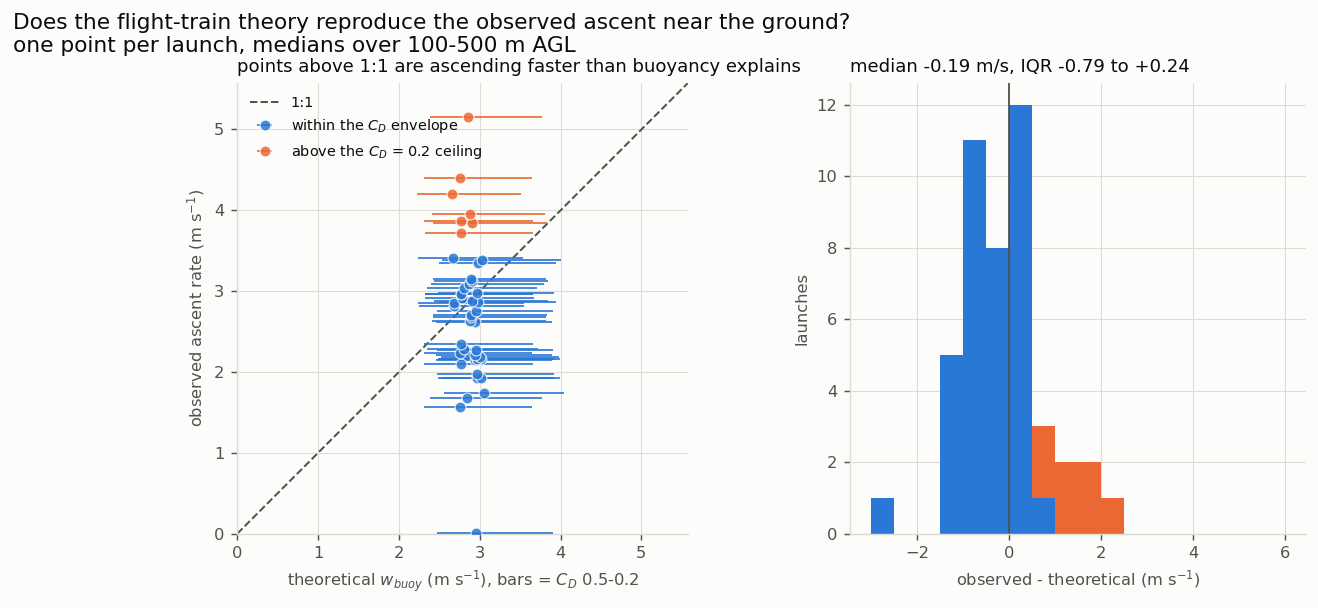

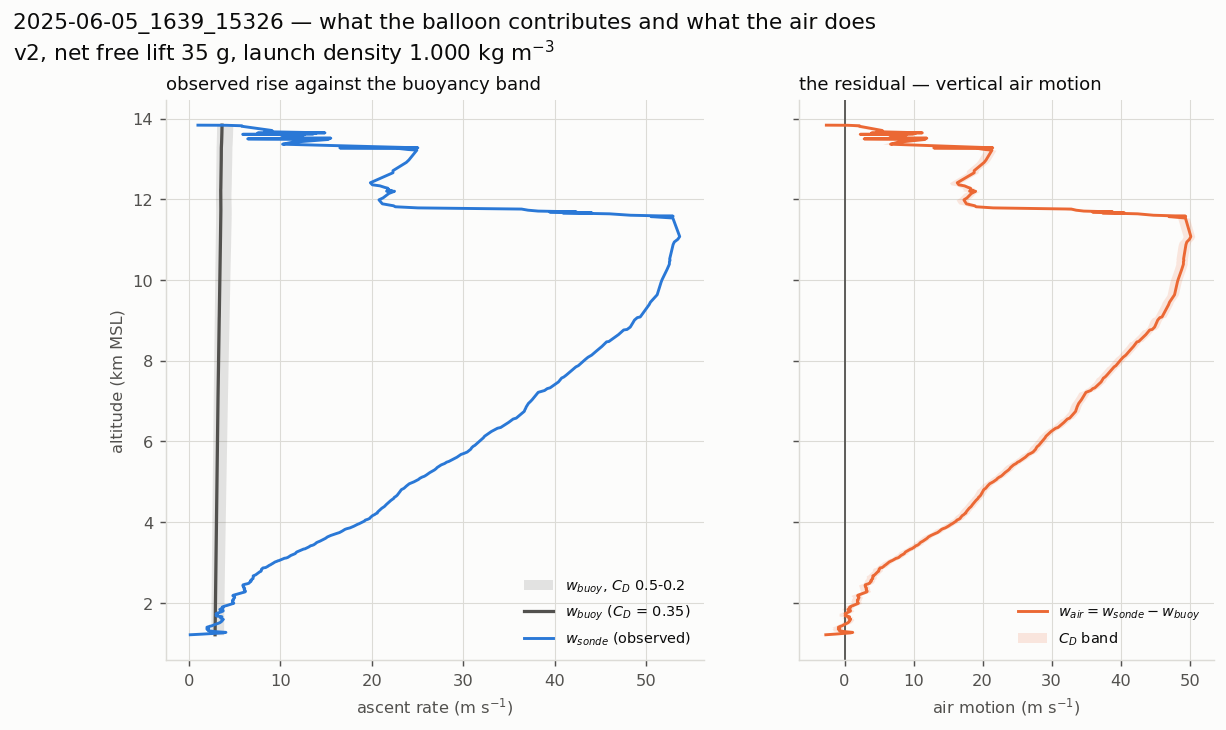


example 2025-06-05_1639_15326: 646 ascent samples, 1.21-13.84 km, w_air median +4.05, max +50.17 m/s
figures: wbuoy_eval.png, wbuoy_profile_example.png


In [14]:
# Palette follows plot_comparison.py: blue = observed, orange = the flagged
# subset, neutral ink = a reference rather than a categorical series.
C_OBS, C_HOT = "#2a78d6", "#eb6834"
INK, INK2, GRID, SURF = "#0b0b0b", "#52514e", "#dcdbd6", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": INK2, "ytick.color": INK2, "font.size": 9,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "axes.axisbelow": True,
    "legend.frameon": False, "figure.dpi": 130,
})

# --- theory vs observation over the same sub-cloud samples -------------------
# Ascent leg of every case at once: `transform("idxmax")` tags each row with the
# index label of its own case's highest sample, and `d` keeps one index running
# in time order across all cases, so a row at or below that label is pre-apex.
apex    = d.groupby("case").alt.transform("idxmax")   # index label of the case's top sample
asc     = (d.index <= apex) & (d.t >= 0)              # bool, ascent leg after launch
in_band = (d.agl > AGL_LO) & (d.agl < AGL_HI)         # bool, inside the sub-cloud band
band = d[asc & in_band]

# Per-case median of the theoretical columns, matched onto `lau` (one row per
# launch) through its "case" column -- hence join(..., on="case"), which keys on
# that column instead of on lau's own 0..N index.
theory = band.groupby("case")[["w_buoy", "w_buoy_lo", "w_buoy_hi"]].median()   # m/s, dim: case
ev = lau.join(theory, on="case")          # DataFrame (dim: launch), observed + theory
ev["excess"] = ev.w_obs - ev.w_buoy       # m/s, ascent not explained by buoyancy
ev["over"]   = ev.w_obs > ev.w_buoy_hi    # bool, faster than even the C_D_MIN ceiling
print(f"{len(ev)} launches; {int(ev.over.sum())} above the C_D={CD_MIN} ceiling")
print(f"excess w_obs - w_buoy: median {ev.excess.median():+.2f}, "
      f"IQR {ev.excess.quantile(0.25):+.2f} to {ev.excess.quantile(0.75):+.2f} m/s")

# figure 1 layout: scatter on the left, histogram of the excess on the right
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(11.2, 4.5), gridspec_kw={"width_ratios": [1.25, 1]},
)
fig.suptitle("Does the flight-train theory reproduce the observed ascent near the ground?\n"
             f"one point per launch, medians over {AGL_LO:.0f}-{AGL_HI:.0f} m AGL",
             x=0.012, y=1.0, ha="left", fontsize=12, color=INK)
fig.subplots_adjust(top=0.88)

# left: theory vs observed per launch, C_D window as horizontal bars, coloured by `over`
for m, c, lab in ((~ev.over, C_OBS, "within the $C_D$ envelope"),
                  (ev.over,  C_HOT, f"above the $C_D$ = {CD_MIN:.1f} ceiling")):
    s = ev[m]
    ax1.errorbar(
        s.w_buoy, s.w_obs, xerr=[s.w_buoy - s.w_buoy_lo, s.w_buoy_hi - s.w_buoy],
        fmt="o", ms=6, color=c, mec=SURF, mew=0.6, ecolor=c, elinewidth=1.1,
        alpha=0.85, capsize=0, zorder=3, label=lab,
    )

# 1:1 reference on square axes; hi (m/s) is the larger data maximum plus 8 % headroom
hi = float(np.nanmax([ev.w_obs.max(), ev.w_buoy_hi.max()])) * 1.08
ax1.plot([0, hi], [0, hi], color=INK2, lw=1.1, ls="--", zorder=2, label="1:1")
ax1.set_xlim(0, hi)
ax1.set_ylim(0, hi)
ax1.set_aspect("equal")
ax1.set_xlabel("theoretical $w_{buoy}$ (m s$^{-1}$), bars = $C_D$ 0.5-0.2")
ax1.set_ylabel("observed ascent rate (m s$^{-1}$)")
ax1.set_title("points above 1:1 are ascending faster than buoyancy explains",
              loc="left", fontsize=10, color=INK, pad=6)
ax1.legend(loc="upper left", fontsize=8)

# right: stacked histogram of observed - theoretical, in 0.5 m/s bins
ax2.axvline(0, color=INK2, lw=1.0, zorder=2)
ax2.hist([ev.excess[~ev.over], ev.excess[ev.over]], bins=np.arange(-3, 6.5, 0.5),
         stacked=True, color=[C_OBS, C_HOT], lw=0)
ax2.set_xlabel("observed - theoretical (m s$^{-1}$)")
ax2.set_ylabel("launches")
ax2.set_title(f"median {ev.excess.median():+.2f} m/s, IQR {ev.excess.quantile(0.25):+.2f} "
              f"to {ev.excess.quantile(0.75):+.2f}",
              loc="left", fontsize=10, color=INK, pad=6)
fig.savefig(OUT / "wbuoy_eval.png", bbox_inches="tight")
plt.show()

# --- one profile ------------------------------------------------------------
# pick the example case; if it was skipped, fall back to the deepest ascent
EXAMPLE = "2025-06-05_1639_15326"
if EXAMPLE not in set(d.case):
    top_alt = d[asc].groupby("case").alt.max()   # m MSL, highest ascent sample per case
    EXAMPLE = top_alt.idxmax()
x = d[(d.case == EXAMPLE) & asc].sort_values("alt")   # ascent samples of the example
z = x.alt / 1000                                      # km MSL

# figure 2 layout: shared altitude axis
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(10.4, 5.6), sharey=True, gridspec_kw={"width_ratios": [1.3, 1]},
)
fig.suptitle(f"{EXAMPLE} — what the balloon contributes and what the air does\n"
             f"{x.version.iloc[0]}, net free lift {1e3*x.L_kg.iloc[0]:.0f} g, "
             f"launch density {x.rho0.iloc[0]:.3f} kg m$^{{-3}}$",
             x=0.012, y=1.0, ha="left", fontsize=12, color=INK)
fig.subplots_adjust(top=0.88)

# left: observed rise against the w_buoy band
ax1.fill_betweenx(z, x.w_buoy_lo, x.w_buoy_hi, color=INK2, alpha=0.15, lw=0,
                  label=f"$w_{{buoy}}$, $C_D$ {CD_MAX}-{CD_MIN}")
ax1.plot(x.w_buoy, z, color=INK2, lw=1.8, label=f"$w_{{buoy}}$ ($C_D$ = {CD_ANCHOR})")
ax1.plot(x.rise, z, color=C_OBS, lw=1.6, label="$w_{sonde}$ (observed)")
ax1.set_xlabel("ascent rate (m s$^{-1}$)")
ax1.set_ylabel("altitude (km MSL)")
ax1.set_title("observed rise against the buoyancy band", loc="left",
              fontsize=10, color=INK, pad=6)
ax1.legend(loc="lower right", fontsize=8)

# right: residual air motion, with the band implied by the C_D window
ax2.axvline(0, color=INK2, lw=1.0)
ax2.plot(x.w_air, z, color=C_HOT, lw=1.6, label="$w_{air} = w_{sonde} - w_{buoy}$")
ax2.fill_betweenx(z, x.rise - x.w_buoy_hi, x.rise - x.w_buoy_lo, color=C_HOT,
                  alpha=0.15, lw=0, label="$C_D$ band")
ax2.set_xlabel("air motion (m s$^{-1}$)")
ax2.set_title("the residual — vertical air motion", loc="left",
              fontsize=10, color=INK, pad=6)
ax2.legend(loc="lower right", fontsize=8)
fig.savefig(OUT / "wbuoy_profile_example.png", bbox_inches="tight")
plt.show()

print(f"\nexample {EXAMPLE}: {len(x)} ascent samples, {z.min():.2f}-{z.max():.2f} km, "
      f"w_air median {x.w_air.median():+.2f}, max {x.w_air.max():+.2f} m/s")
print("figures: wbuoy_eval.png, wbuoy_profile_example.png")